In [3]:
from PIL import Image
import pytesseract
import argparse
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import csv
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet

In [7]:
image_path = "photos/bill.jpg"
# os.listdir(path)

In [13]:
# Read an image
image = cv2.imread(filename = image_path, flags=0)
# flags = 0 grayscale
image

array([[15,  9, 12, ...,  9, 10, 10],
       [ 6, 11, 12, ..., 10, 10, 11],
       [12, 15, 12, ..., 12, 13, 12],
       ...,
       [26, 22, 16, ..., 27, 25, 29],
       [21, 32, 26, ..., 22, 20, 18],
       [27, 29, 29, ..., 19, 15, 19]], dtype=uint8)

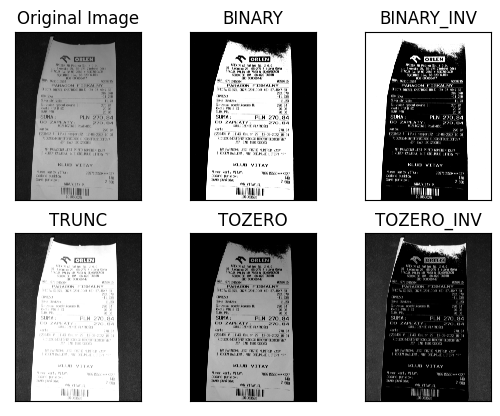

In [19]:

# cv2.threshold(image_path, 127, 255, cv2.THRESH_BINARY)

ret,thresh1 = cv2.threshold(image,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(image,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(image,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(image,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(image,127,255,cv2.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [image, thresh1, thresh2, thresh3, thresh4, thresh5]

for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray',vmin=0,vmax=255)
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()


In [42]:
# convert image into text
text = (pytesseract.image_to_string(image)).lower()
text = text.split('\n')
text = [sentence.strip() for sentence in text]
text = [sentence for sentence in text if len(sentence) != 0]

print(text)


['= tt orlen', 'apexim ab paliwa sp. z 0.0.', '{l. lwowska 25, 65-275 zielona gora', 'stacja paliw nr 7663 w sekowicach', 'sekowice 19a, 66-620 gubin', 'bdo 000066447', 'nip: 9731015564 w359215', '...... paragon fiskalny', 'efecta diesel cn27102011d(4) (b) 37.46*7.53', 'ae 282.078', 'cbn -11.238', 'zeca? apna ngnere b: 70.', 'kwo ks ptu b 8% 20. 06', 'suma ptu', 'karta', 'f208492 a', 'tmi kasjer:22 1;', 'nr paragony jest przed', '| kodem kasjera, nie obej', 'klub vitay', 'numer karty vitay- 789715550 *** «39', 'dodano punktow- 1g', 'suma nun ktow: 2 680', 'wh. vitay pl ok', 'anil', '101063626']


In [43]:
print(text[3])

stacja paliw nr 7663 w sekowicach
